In [5]:
import numpy as np
import pandas as pd

In [6]:
df=pd.read_csv("/content/full_dataset.csv")

In [7]:
df.head()

,label,acc_x_0,acc_x_1,acc_x_2,acc_x_3,acc_x_4,acc_x_5,acc_x_6,acc_x_7,acc_x_8,...,gy_z_150,gy_z_151,gy_z_152,gy_z_153,gy_z_154,gy_z_155,gy_z_156,gy_z_157,gy_z_158,gy_z_159
0,idle,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,1.6440,1.6856,1.5975,1.4654,1.5300,1.5300,1.5900,1.5629,1.4559,1.4666
1,fall,-0.0008,0.0181,0.1298,0.1815,0.1867,0.0526,0.0188,0.0228,0.3152,...,1.2886,1.2177,1.3184,1.1846,0.7587,0.8685,0.7453,0.5273,0.8011,0.8872
2,step,0.0200,0.0200,0.0276,0.0201,0.0000,0.0000,0.0000,0.0107,0.0291,...,-0.5565,-0.1801,-0.2183,-0.3190,-0.3448,-0.3691,-0.3310,-0.2755,-0.2912,-0.2433
3,motion,-0.0348,-0.0104,0.0309,0.0373,0.0498,0.0600,0.0984,0.0810,0.0559,...,-0.5500,-0.5500,-0.2313,-0.1530,-0.1978,-0.3943,-0.4711,-0.1704,-0.3037,-0.5155
4,step,0.0200,0.0172,0.0100,0.0020,-0.0099,0.0024,0.0155,0.0357,0.0200,...,-0.5644,-0.5155,-0.5806,-0.6057,-0.5801,-0.5544,-0.5491,-0.5115,-0.4625,-0.3833


In [8]:
df.isnull().count()

,0
label,160
acc_x_0,160
acc_x_1,160
acc_x_2,160
acc_x_3,160
...,...
gy_z_155,160
gy_z_156,160
gy_z_157,160
gy_z_158,160


In [9]:
df.describe()

,acc_x_0,acc_x_1,acc_x_2,acc_x_3,acc_x_4,acc_x_5,acc_x_6,acc_x_7,acc_x_8,acc_x_9,...,gy_z_150,gy_z_151,gy_z_152,gy_z_153,gy_z_154,gy_z_155,gy_z_156,gy_z_157,gy_z_158,gy_z_159
count,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,...,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,0.019386,0.023758,0.029116,0.029559,0.030321,0.025803,0.024854,0.029618,0.040863,-0.002831,...,0.570025,0.494766,0.444774,0.506824,0.352524,0.453409,0.470753,0.498833,0.593714,0.636267
std,0.168756,0.204312,0.207765,0.209399,0.215238,0.197174,0.210010,0.253022,0.258793,0.341709,...,5.346978,5.230603,5.075507,4.912191,4.766225,4.771148,4.519687,4.415391,4.551986,4.678756
min,-1.170100,-1.130400,-1.110000,-1.104000,-1.109800,-1.100000,-1.100000,-1.084400,-1.059700,-3.494800,...,-15.999200,-17.574100,-19.262100,-20.636600,-24.585600,-25.255100,-26.158000,-27.290000,-28.995200,-31.889200
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000050,0.000000,0.000000,0.000000,...,-0.514200,-0.522750,-0.498850,-0.497650,-0.490000,-0.490000,-0.504400,-0.519600,-0.491500,-0.502300
50%,0.020000,0.018000,0.019700,0.014650,0.013350,0.020000,0.016850,0.014000,0.019850,0.014300,...,-0.240000,-0.250500,-0.197100,-0.282300,-0.289000,-0.304600,-0.310000,-0.275900,-0.289300,-0.180000
75%,0.027950,0.025175,0.030000,0.029925,0.023400,0.025600,0.030000,0.030000,0.029550,0.022875,...,1.309700,1.231950,1.318400,1.184600,1.279200,1.424100,1.324300,1.362500,1.419250,1.444250
max,1.364100,2.032800,2.102900,2.143400,2.192600,1.941600,2.115700,1.966300,2.112700,1.657500,...,55.384800,52.855500,50.100500,47.548300,45.430200,43.343400,39.418600,37.680800,36.905700,36.705600


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Columns: 961 entries, label to gy_z_159
dtypes: float64(960), object(1)
memory usage: 1.2+ MB


In [11]:
import sklearn.model_selection
from sklearn.preprocessing import LabelEncoder

In [12]:
label = ['idle','fall','step','motion',]

In [13]:
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(label)

In [14]:
print(encoded_labels) # Output: [2 1 0 1 2] (or similar, order depends on internal sort)
print(label_encoder.classes_)

[1 0 3 2]
['fall' 'idle' 'motion' 'step']


In [15]:
df['encoded_label'] = label_encoder.fit_transform(df['label'])
display(df.head())

,label,acc_x_0,acc_x_1,acc_x_2,acc_x_3,acc_x_4,acc_x_5,acc_x_6,acc_x_7,acc_x_8,...,gy_z_151,gy_z_152,gy_z_153,gy_z_154,gy_z_155,gy_z_156,gy_z_157,gy_z_158,gy_z_159,encoded_label
0,idle,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,1.6856,1.5975,1.4654,1.5300,1.5300,1.5900,1.5629,1.4559,1.4666,1
1,fall,-0.0008,0.0181,0.1298,0.1815,0.1867,0.0526,0.0188,0.0228,0.3152,...,1.2177,1.3184,1.1846,0.7587,0.8685,0.7453,0.5273,0.8011,0.8872,0
2,step,0.0200,0.0200,0.0276,0.0201,0.0000,0.0000,0.0000,0.0107,0.0291,...,-0.1801,-0.2183,-0.3190,-0.3448,-0.3691,-0.3310,-0.2755,-0.2912,-0.2433,3
3,motion,-0.0348,-0.0104,0.0309,0.0373,0.0498,0.0600,0.0984,0.0810,0.0559,...,-0.5500,-0.2313,-0.1530,-0.1978,-0.3943,-0.4711,-0.1704,-0.3037,-0.5155,2
4,step,0.0200,0.0172,0.0100,0.0020,-0.0099,0.0024,0.0155,0.0357,0.0200,...,-0.5155,-0.5806,-0.6057,-0.5801,-0.5544,-0.5491,-0.5115,-0.4625,-0.3833,3


The `encoded_label` column now contains numerical representations of your original labels. Here's how the original labels are mapped to the encoded numbers:


In [16]:
for i, label_class in enumerate(label_encoder.classes_):
    print(f"{label_class}: {i}")

fall: 0
idle: 1
motion: 2
step: 3


In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LinearRegression, LogisticRegression, ElasticNet
from sklearn.ensemble import RandomForestClassifier

In [18]:
target = df['label']
y = df['encoded_label']
x = df.drop(['label', 'encoded_label'], axis=1)

In [19]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42)

# Impute missing values with the mean
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [20]:
Logreg=LogisticRegression

In [21]:
Logreg_model = Logreg()
Logreg_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [22]:
y_pred = Logreg_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 47.16981132075472


In [23]:
model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=0)

In [24]:
model.fit(x_train, y_train)

ElasticNet(random_state=0)

In [25]:
y_pred = model.predict(x_test)

In [26]:
print(f"R^2 score on test data: {model.score(x_test, y_test)}")

R^2 score on test data: 0.3249235054767593


In [27]:
import numpy as np

# Round the continuous predictions to the nearest integer
y_pred_discrete = np.round(y_pred)

# Ensure predictions are within the valid range of encoded labels (0, 1, 2, 3)
# np.clip(value, min, max) ensures values are not below min or above max
y_pred_discrete = np.clip(y_pred_discrete, a_min=0, a_max=len(label_encoder.classes_)-1)

print("Accuracy:", accuracy_score(y_test, y_pred_discrete)*100)

Accuracy: 39.62264150943396


Let's try training a `RandomForestClassifier` to see if we can get better performance. Random Forests are powerful ensemble learning methods that can handle high-dimensional data and are less sensitive to feature scaling.

In [28]:
# Initialize and train a RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42 , n_estimators = 8000)
rf_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(x_test)

# Evaluate the model's accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf) * 100
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.2f}%")

Random Forest Classifier Accuracy: 86.79%


In [29]:
from sklearn.svm import SVC
# Use SVC (Classification) instead of SVR (Regression) for categorical labels
classifier = SVC(kernel='rbf', C=100, gamma='scale')
classifier.fit(x_train, y_train)

# 5. Predict
y_pred = classifier.predict(x_test)
accuracy_svc = accuracy_score(y_test, y_pred) * 100
print(f"SVM Classifier Accuracy: {accuracy_svc:.2f}%")

SVM Classifier Accuracy: 49.06%


In [30]:
from sklearn.model_selection import RandomizedSearchCV, KFold

# 1. Define the parameter grid to search
param_dist = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Instantiate RandomizedSearchCV with param_distributions
rcv = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    scoring='accuracy',
    refit=True,
    cv=kfold,
    verbose=2,
    n_iter=5,
    random_state=42
)

# 3. Fit the search (this might take a moment)
rcv.fit(x_train, y_train)
print("Best parameters:", rcv.best_params_)
print("Best score:", rcv.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=1000; total time=   4.4s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=1000; total time=   2.6s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=1000; total time=   2.5s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=1000; total time=   2.6s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=1000; total time=   2.6s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   2.2s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.9s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   2.0s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.4s
[CV] END max_depth

In [31]:
df.shape

(160, 962)

In [32]:
# evaluation_metrics.py

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    RocCurveDisplay
)
from sklearn.preprocessing import label_binarize


def evaluate_with_plots(model, X_test, y_test, label_encoder):
    """
    Detailed evaluation with plots and metrics
    """

    y_pred = model.predict(X_test)

    print("\n" + "="*50)
    print("CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_encoder.classes_)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    # ---------------- ROC Curve (Multiclass) ----------------
    y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
    y_score = model.predict_proba(X_test)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(len(label_encoder.classes_)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC for each class
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(label_encoder.classes_):
        plt.plot(fpr[i], tpr[i], label=f"{class_name} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title("ROC Curve (Multiclass)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    print("\nROC AUC Scores per class:")
    for i, class_name in enumerate(label_encoder.classes_):
        print(f"{class_name}: {roc_auc[i]:.3f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fall       0.64      0.82      0.72        11
        idle       0.80      1.00      0.89         8
      motion       0.86      0.57      0.69        21
        step       0.87      1.00      0.93        13

    accuracy                           0.79        53
   macro avg       0.79      0.85      0.81        53
weighted avg       0.81      0.79      0.78        53



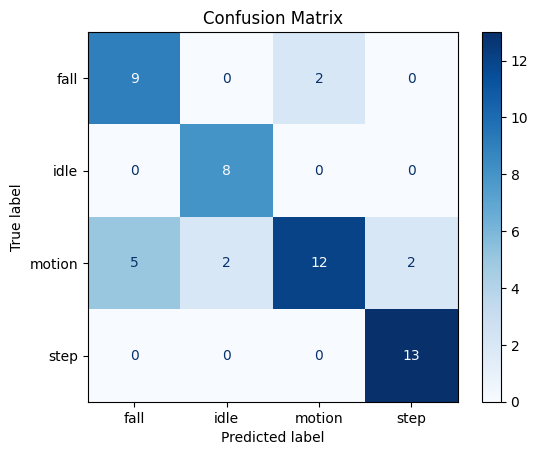

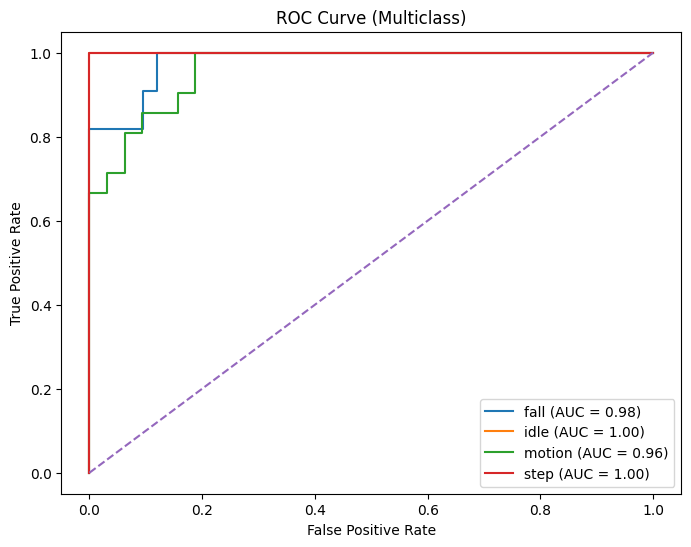


ROC AUC Scores per class:
fall: 0.981
idle: 1.000
motion: 0.963
step: 1.000


In [35]:
best_model = rcv.best_estimator_
evaluate_with_plots(best_model, x_test, y_test, label_encoder)